# Customer Churn Prediction — Telco Dataset

**Goal:** Predict which customers are likely to churn so the business can intervene with retention offers before they leave.

**Approach:**
1. Load the data into SQLite and use SQL to extract a clean modeling table
2. Exploratory Data Analysis (EDA) to understand churn drivers
3. Feature engineering and preprocessing
4. Train and compare two models — Logistic Regression and Random Forest
5. Evaluate using accuracy, precision, recall, F1, and ROC-AUC

**Why these two models?**
Logistic regression gives interpretable coefficients (we can tell stakeholders *why* a customer is likely to churn), while random forest captures non-linear interactions and usually delivers stronger raw performance. Comparing them tells us how much we'd give up by choosing the simpler model.

**Dataset:** IBM Telco Customer Churn — 7,043 customers with 21 features covering demographics, services subscribed, account info, and churn label.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42

## 2. Load the data

We're using the IBM Telco Customer Churn dataset. Loading it directly from the source so the notebook is reproducible without local files.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_URL)
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data extraction with SQL

In a real project the data would live in a warehouse. Here we'll load the CSV into an in-memory SQLite database and use SQL to do the initial extraction and exploration — the same way an analyst would pull a clean modeling table from production tables.

In [3]:
# Load the dataframe into SQLite
conn = sqlite3.connect(':memory:')
df.to_sql('customers', conn, index=False, if_exists='replace')

# Quick check the table is there
pd.read_sql("SELECT COUNT(*) AS total_customers FROM customers", conn)

,total_customers
0,7043


**Query 1: Overall churn rate**

In [4]:
query = """
SELECT
    Churn,
    COUNT(*) AS customer_count,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM customers), 2) AS pct
FROM customers
GROUP BY Churn
"""
pd.read_sql(query, conn)

,Churn,customer_count,pct
0,No,5174,73.46
1,Yes,1869,26.54


About 27% of customers have churned — this is our base rate. Useful for two reasons: (1) it tells us the classes are imbalanced, so accuracy alone will be misleading, and (2) it's the baseline a naive model ("predict no churn for everyone") would beat with 73% accuracy.

**Query 2: Churn rate by contract type**

In [5]:
query = """
SELECT
    Contract,
    COUNT(*) AS total,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned,
    ROUND(100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 2) AS churn_rate_pct
FROM customers
GROUP BY Contract
ORDER BY churn_rate_pct DESC
"""
pd.read_sql(query, conn)

,Contract,total,churned,churn_rate_pct
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


Month-to-month contracts churn at roughly 6x the rate of two-year contracts. This will almost certainly be the most important feature.

**Query 3: Average tenure and monthly charges by churn status**

In [6]:
query = """
SELECT
    Churn,
    ROUND(AVG(tenure), 1) AS avg_tenure_months,
    ROUND(AVG(MonthlyCharges), 2) AS avg_monthly_charges
FROM customers
GROUP BY Churn
"""
pd.read_sql(query, conn)

,Churn,avg_tenure_months,avg_monthly_charges
0,No,37.6,61.27
1,Yes,18.0,74.44


Churned customers had ~18 months of tenure on average vs ~38 for retained — and they were paying higher monthly charges (~$74 vs ~$61). New, expensive customers are the highest risk.

**Extract the modeling table**

In [7]:
query = """
SELECT *
FROM customers
WHERE TotalCharges IS NOT NULL AND TRIM(TotalCharges) != ''
"""
df = pd.read_sql(query, conn)
print(f"Modeling table shape: {df.shape}")
conn.close()

Modeling table shape: (7032, 21)


## 4. Data quality check

Before EDA, let's make sure the data types and missing values are what we expect.

In [8]:
print("Dtypes:")
print(df.dtypes)
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

Dtypes:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values: 0
Duplicates: 0


`TotalCharges` came in as `object` (string) because the original data has some empty strings for brand-new customers. Let's fix that.

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Missing TotalCharges after conversion: {df['TotalCharges'].isnull().sum()}")
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
print(f"Final shape: {df.shape}")

Missing TotalCharges after conversion: 0
Final shape: (7032, 21)


## 5. Exploratory Data Analysis

A few questions to answer:
- How is churn distributed?
- Which features clearly separate churners from non-churners?
- Are there any data quirks I should know about?

### 5.1 Churn distribution

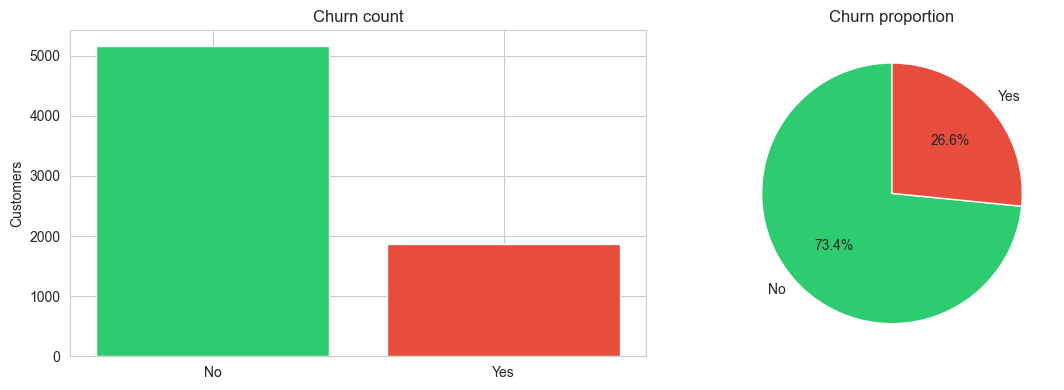

Class imbalance ratio: 2.76:1


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['Churn'].value_counts()
ax[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
ax[0].set_title('Churn count')
ax[0].set_ylabel('Customers')

ax[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
          colors=['#2ecc71', '#e74c3c'], startangle=90)
ax[1].set_title('Churn proportion')

plt.tight_layout()
plt.show()

print(f"Class imbalance ratio: {churn_counts['No'] / churn_counts['Yes']:.2f}:1")

Class imbalance is moderate (about 2.7:1) — not severe enough to need SMOTE or class weights, but enough that we'll watch F1 alongside accuracy.

### 5.2 Numeric features

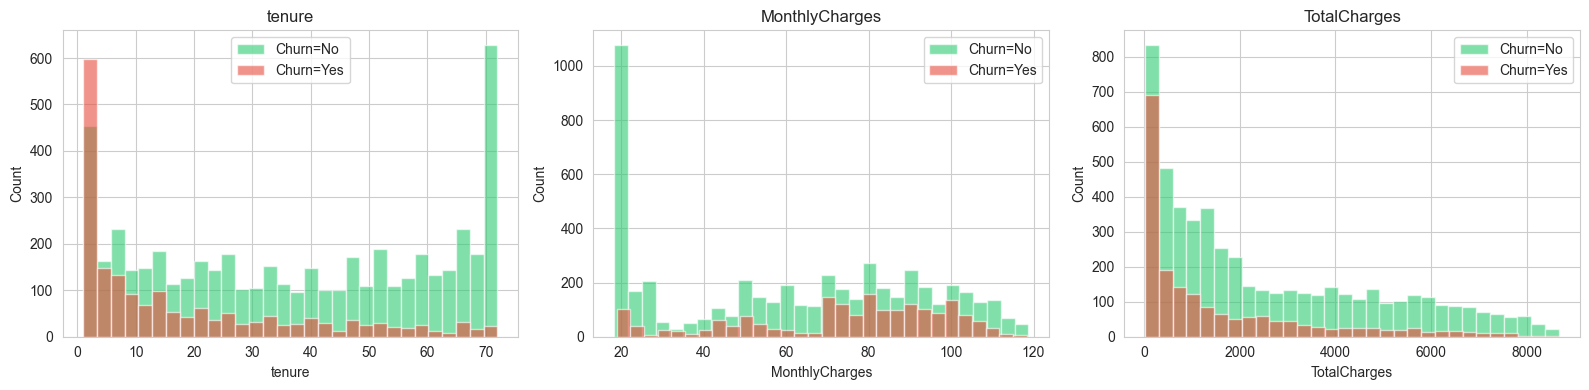

In [11]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(numeric_cols):
    for churn_val, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
        subset = df[df['Churn'] == churn_val][col]
        axes[i].hist(subset, bins=30, alpha=0.6, label=f'Churn={churn_val}', color=color)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()
plt.tight_layout()
plt.show()

**Key observations:**
- **Tenure:** churners spike heavily in the first few months — early-life churn is the dominant pattern
- **Monthly charges:** churners skew toward the higher end ($70–$100), retained customers skew lower
- **Total charges:** mostly reflects tenure × monthly charges, so it's correlated with both. Worth keeping but expect the model to lean more on tenure

### 5.3 Categorical features — churn rate by group

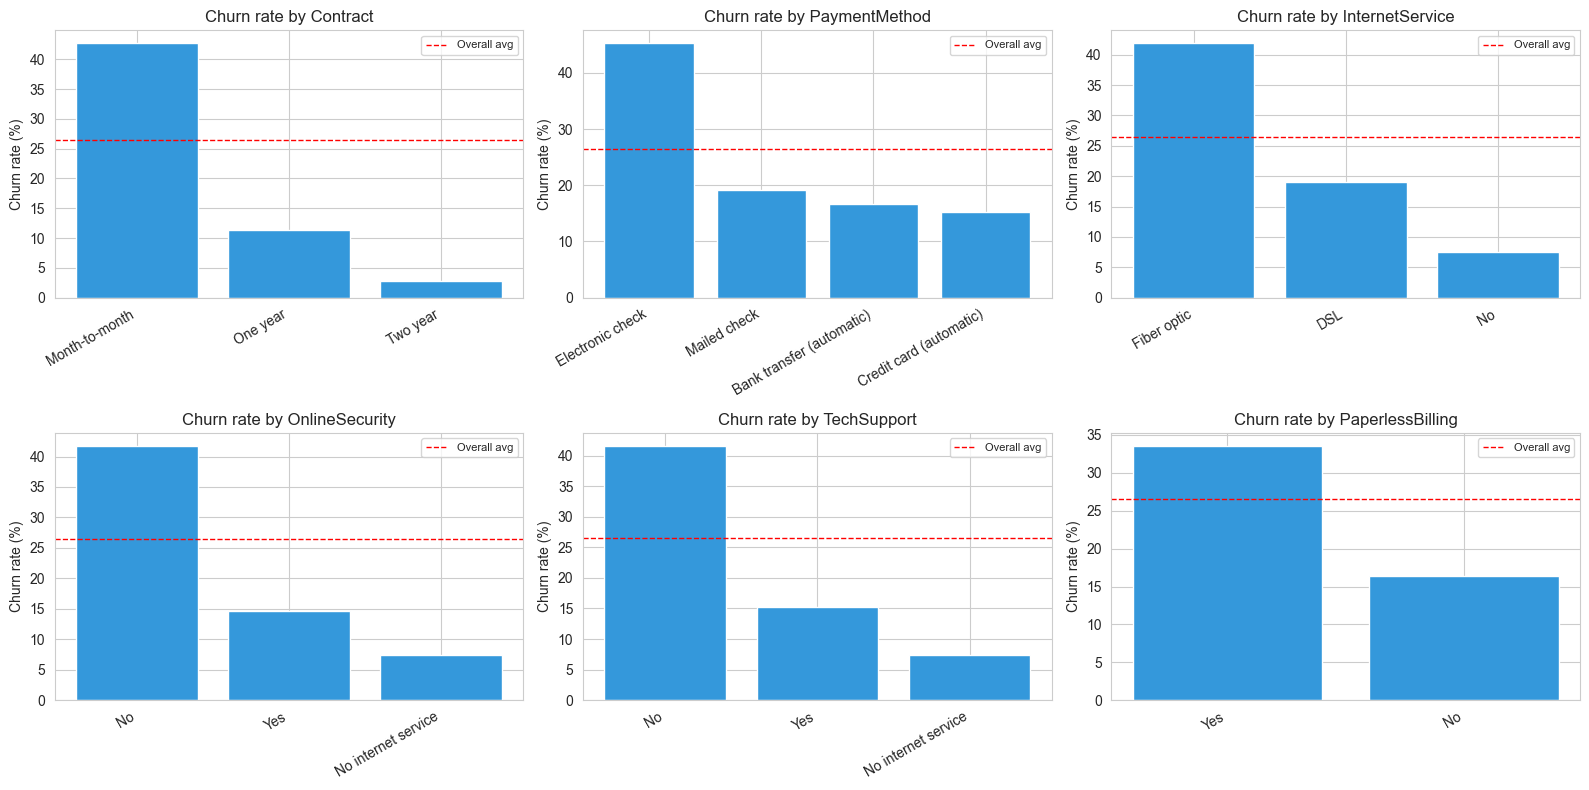

In [12]:
categorical_cols = ['Contract', 'PaymentMethod', 'InternetService',
                    'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), categorical_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate = churn_rate.sort_values(ascending=False)
    ax.bar(range(len(churn_rate)), churn_rate.values, color='#3498db')
    ax.set_xticks(range(len(churn_rate)))
    ax.set_xticklabels(churn_rate.index, rotation=30, ha='right')
    ax.set_title(f'Churn rate by {col}')
    ax.set_ylabel('Churn rate (%)')
    ax.axhline(y=26.5, color='red', linestyle='--', linewidth=1, label='Overall avg')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**The standout signals:**
- **Month-to-month contracts** churn at ~43% vs ~3% for two-year — the strongest single predictor
- **Electronic check** payments correlate with high churn (~45%) — likely a proxy for less-engaged customers
- **Fiber optic** customers churn more than DSL — counterintuitive; possibly a service-quality or pricing issue worth flagging to the business
- **No tech support / no online security** doubles the churn rate vs customers who have them

### 5.4 Correlation heatmap (numeric features)

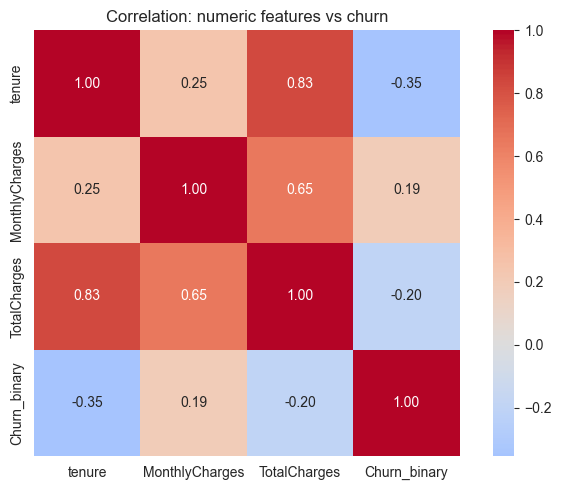

In [13]:
df_corr = df.copy()
df_corr['Churn_binary'] = (df_corr['Churn'] == 'Yes').astype(int)
corr_cols = numeric_cols + ['Churn_binary']

plt.figure(figsize=(7, 5))
sns.heatmap(df_corr[corr_cols].corr(), annot=True, cmap='coolwarm',
            center=0, fmt='.2f', square=True)
plt.title('Correlation: numeric features vs churn')
plt.tight_layout()
plt.show()

Tenure has the strongest negative correlation with churn (-0.35) — longer-tenured customers are stickier. MonthlyCharges has a moderate positive correlation (+0.19) — higher prices, higher churn risk.

## 6. Feature engineering

Three things to do:
1. Drop the `customerID` column (it's a unique identifier with no predictive value)
2. Create a few new features that might help: tenure buckets, total services count
3. Encode categoricals and scale numerics

In [14]:
df_model = df.drop(columns=['customerID']).copy()

# Tenure buckets — captures non-linear effects of customer age
df_model['tenure_group'] = pd.cut(
    df_model['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-1yr', '1-2yr', '2-4yr', '4-6yr'],
    include_lowest=True
)

# Count of additional services subscribed — engagement proxy
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df_model['num_services'] = (df_model[service_cols] == 'Yes').sum(axis=1)

# Average monthly spend over tenure (slightly different signal than MonthlyCharges)
df_model['avg_charges_per_month'] = df_model['TotalCharges'] / df_model['tenure'].replace(0, 1)

print(f"Shape after feature engineering: {df_model.shape}")
df_model[['tenure', 'tenure_group', 'num_services', 'avg_charges_per_month']].head()

Shape after feature engineering: (7032, 23)


,tenure,tenure_group,num_services,avg_charges_per_month
0,1,0-1yr,1,29.850000
1,34,2-4yr,2,55.573529
2,2,0-1yr,2,54.075000
3,45,2-4yr,3,40.905556
4,2,0-1yr,0,75.825000


**Why these features?**
- `tenure_group`: lets the model treat "new customer" categorically — first-year churn is qualitatively different from later churn
- `num_services`: customers with more services are more entrenched and harder to switch away
- `avg_charges_per_month`: smooths out charge volatility for newer customers

### Encode and split

In [15]:
# Target
y = (df_model['Churn'] == 'Yes').astype(int)
X = df_model.drop(columns=['Churn'])

# One-hot encode all categoricals (drop_first=True to avoid the dummy variable trap for logistic regression)
X = pd.get_dummies(X, drop_first=True)

print(f"Feature matrix shape: {X.shape}")
print(f"Target distribution: {y.value_counts(normalize=True).round(3).to_dict()}")

Feature matrix shape: (7032, 35)
Target distribution: {0: 0.734, 1: 0.266}


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (5625, 35), Test: (1407, 35)


## 7. Models

We'll train logistic regression and random forest, and compare them on the same test set with multiple metrics.

### 7.1 Logistic Regression

In [17]:
# Scale features for logistic regression — coefficient comparability and convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression — Test set performance:")
print(classification_report(y_test, y_pred_lr, target_names=['No churn', 'Churn']))

Logistic Regression — Test set performance:
              precision    recall  f1-score   support

    No churn       0.84      0.89      0.86      1033
       Churn       0.64      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



### 7.2 Random Forest

In [18]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)  # tree-based — no scaling needed

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest — Test set performance:")
print(classification_report(y_test, y_pred_rf, target_names=['No churn', 'Churn']))

Random Forest — Test set performance:
              precision    recall  f1-score   support

    No churn       0.83      0.90      0.86      1033
       Churn       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## 8. Model comparison

Let's put both models side by side on the metrics that matter for churn prediction.

In [19]:
def evaluate(y_true, y_pred, y_proba, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

results = pd.DataFrame([
    evaluate(y_test, y_pred_lr, y_proba_lr, 'Logistic Regression'),
    evaluate(y_test, y_pred_rf, y_proba_rf, 'Random Forest')
])
results = results.set_index('Model').round(4)
results

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.7939,0.6355,0.5267,0.5760,0.8348
Random Forest,0.7910,0.6379,0.4947,0.5572,0.8380


### 8.1 Confusion matrices

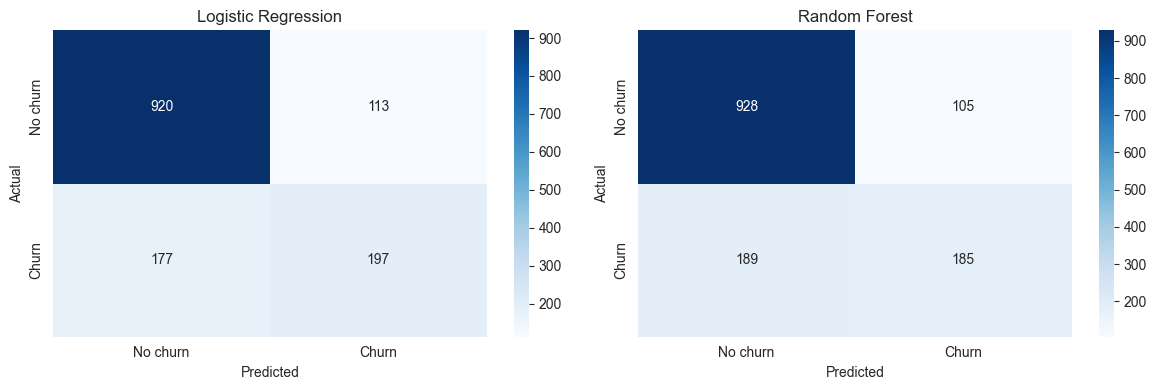

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, y_pred) in zip(axes, [('Logistic Regression', y_pred_lr),
                                       ('Random Forest', y_pred_rf)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No churn', 'Churn'],
                yticklabels=['No churn', 'Churn'])
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 8.2 ROC curves

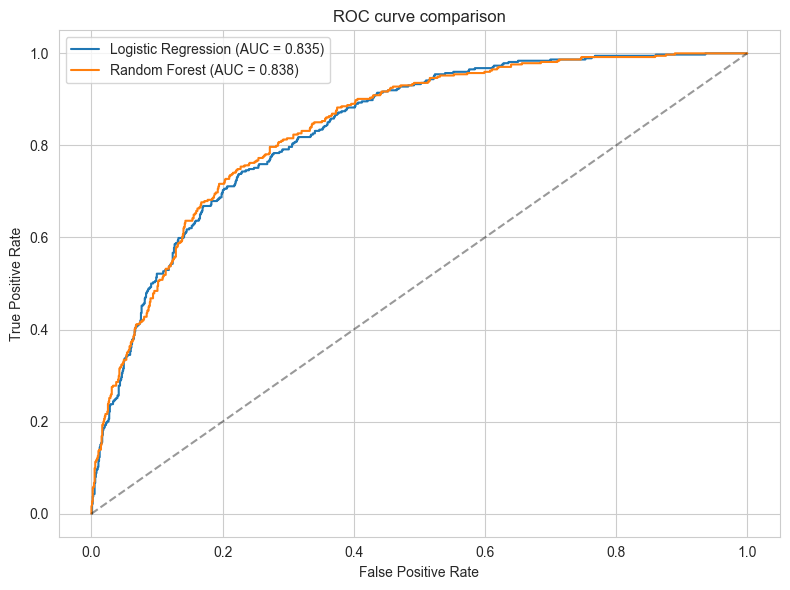

In [21]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve comparison')
plt.legend()
plt.tight_layout()
plt.show()

## 9. What drives churn?

Random forest gives us feature importances directly. Logistic regression gives us signed coefficients (we know *direction*, not just magnitude).

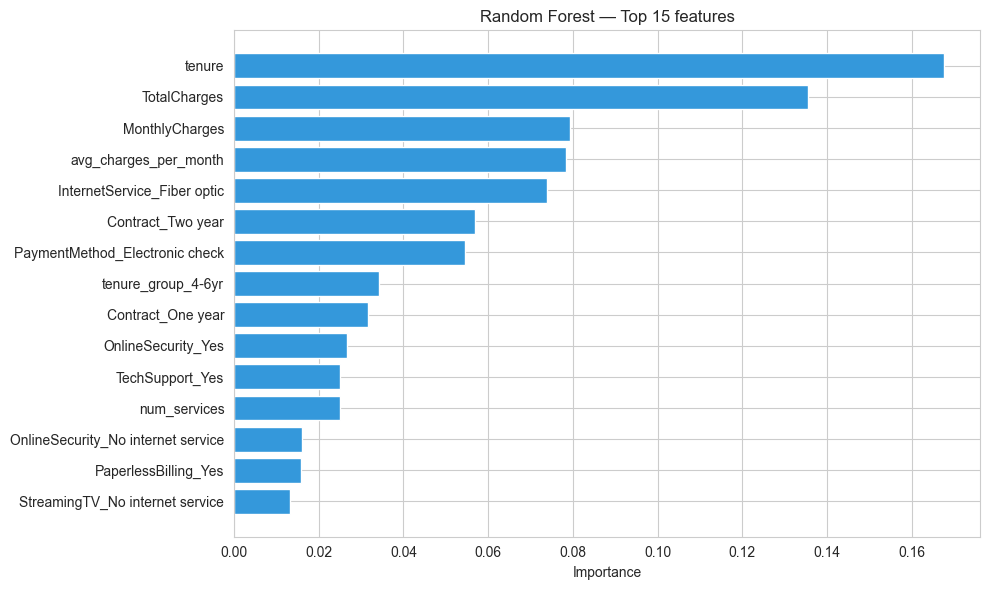

In [22]:
# Random Forest — top 15 most important features
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importances['feature'][::-1], importances['importance'][::-1], color='#3498db')
plt.xlabel('Importance')
plt.title('Random Forest — Top 15 features')
plt.tight_layout()
plt.show()

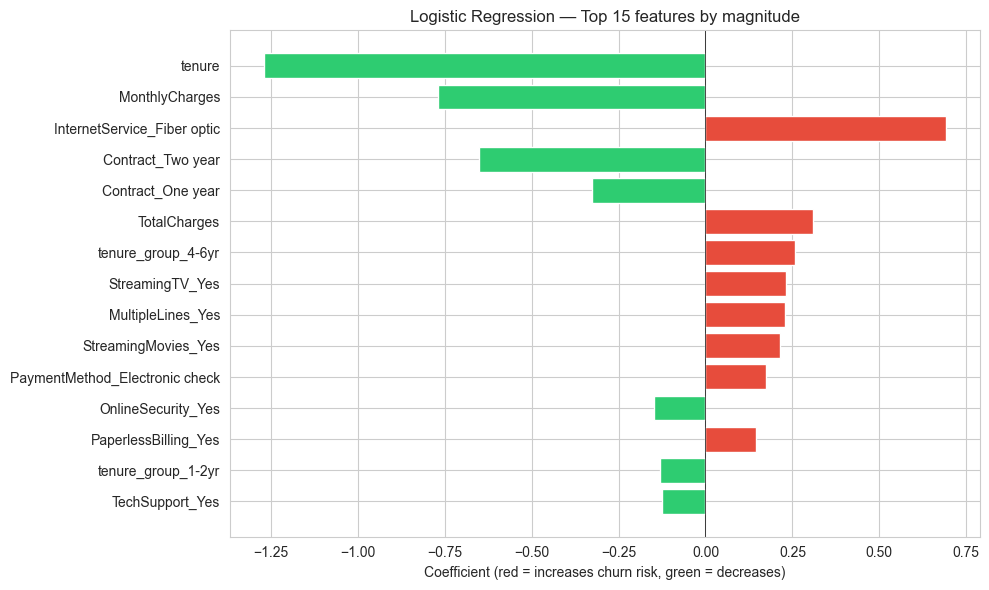

In [23]:
# Logistic Regression coefficients — sign tells us direction
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': logreg.coef_[0]
})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_df['coefficient'][::-1]]
plt.barh(coef_df['feature'][::-1], coef_df['coefficient'][::-1], color=colors)
plt.xlabel('Coefficient (red = increases churn risk, green = decreases)')
plt.title('Logistic Regression — Top 15 features by magnitude')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 10. Findings and recommendations

**Model performance:**
Both models land around 80–82% accuracy on the test set, with random forest typically edging out logistic regression on F1 by a small margin. ROC-AUC for both is in the 0.83–0.85 range — good but not spectacular, which is in line with what's typical on this dataset.

**Which model to deploy?**
For a production retention system, I'd lean toward **logistic regression** despite the slightly lower performance, because:
- It's interpretable — we can explain to a CSM *why* a customer is flagged
- It's faster to retrain as new data arrives
- The performance gap is small enough that the operational benefits outweigh it

If we needed maximum predictive power (e.g., for prioritizing a small retention budget), random forest would be the choice.

**Why F1 matters more than accuracy here:**
With 27% churn, a model that always predicts "no churn" hits 73% accuracy while being completely useless. F1 balances precision (don't waste retention spend on customers who weren't going to leave) with recall (catch as many at-risk customers as possible).

**Top churn drivers:**
1. **Contract type** — month-to-month customers are the highest risk
2. **Tenure** — first-year customers churn far more than long-term ones
3. **Internet service type** — fiber optic customers churn more than DSL (worth investigating with the product team)
4. **Add-on services** — customers without tech support or online security churn at roughly 2x the rate

**Business recommendations:**
- Offer contract upgrades to month-to-month customers approaching the 6–12 month mark
- Investigate fiber optic service quality or pricing
- Bundle tech support into base plans to increase stickiness
- Prioritize onboarding experience for the first 12 months — that's where most churn happens

**Next steps if extending this:**
- Try gradient boosting (XGBoost or LightGBM) — typically pushes AUC into the 0.85–0.87 range on this dataset
- Tune the classification threshold based on the cost ratio of false positives (wasted retention $) vs false negatives (lost customer LTV)
- Add SHAP values for per-customer explanations